# Customer Segmentation — K-Means Clustering on RFM Features

We take the RFM table built in notebook 02 and cluster customers using K-Means. The optimal number of clusters is chosen by comparing the elbow curve (inertia) and silhouette scores across k = 2 … 10. We then profile each cluster, assign marketing personas, and visualise the segments in PCA space.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import warnings; warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

sys.path.insert(0, os.getcwd())
from utils import preprocess_features, find_optimal_k, profile_clusters

In [2]:
rfm = pd.read_csv('data/customer_rfm.csv')
print('RFM shape:', rfm.shape)
rfm.head()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 2. Preprocess: Log-Transform + Scale

All three RFM features are right-skewed (shown in notebook 02). We apply `log1p` to compress the long tails, then `StandardScaler` to give each feature unit variance. This ensures K-Means distance calculations are not dominated by the raw scale of Monetary values.

In [3]:
rfm_log, X_scaled, scaler, features = preprocess_features(rfm)
print('Scaled array shape:', X_scaled.shape)
pd.DataFrame(X_scaled, columns=features).describe().round(3)

Scaled array shape: (4338, 3)


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-4.005
25%,-0.661,-0.955,-0.686
50%,0.090,-0.362,-0.062
75%,0.845,0.653,0.654
max,1.564,5.859,4.732


## 3. Elbow Method — Inertia vs k

We fit K-Means for k = 2 … 10 and plot the within-cluster sum of squares (inertia). The "elbow" — where the rate of decrease slows markedly — suggests a good trade-off between cluster count and compactness.

In [4]:
metrics_df = find_optimal_k(X_scaled, k_range=range(2, 11))
metrics_df.round(4)

,k,inertia,silhouette
0,2,6481.2253,0.4329
1,3,4867.8466,0.3365
2,4,3938.5100,0.3371
3,5,3295.9763,0.3161
4,6,2855.0112,0.3133
5,7,2548.9143,0.3100
6,8,2336.7775,0.3008
7,9,2155.6482,0.2817
8,10,1999.9033,0.2787


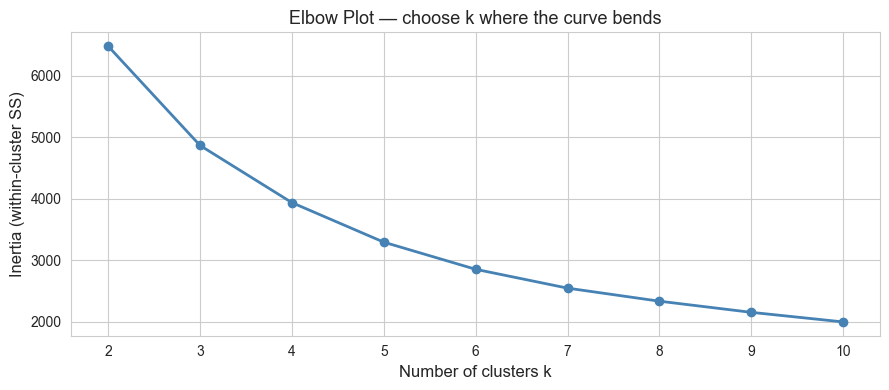

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(metrics_df['k'], metrics_df['inertia'], marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of clusters k', fontsize=12)
ax.set_ylabel('Inertia (within-cluster SS)', fontsize=12)
ax.set_title('Elbow Plot — choose k where the curve bends', fontsize=13)
ax.set_xticks(metrics_df['k'])
plt.tight_layout(); plt.show()

## 4. Silhouette Analysis — Pick Optimal k

The silhouette score measures how well each point fits its own cluster versus the nearest neighbouring cluster (range −1 to +1; higher is better). We pick the k that maximises the silhouette score.

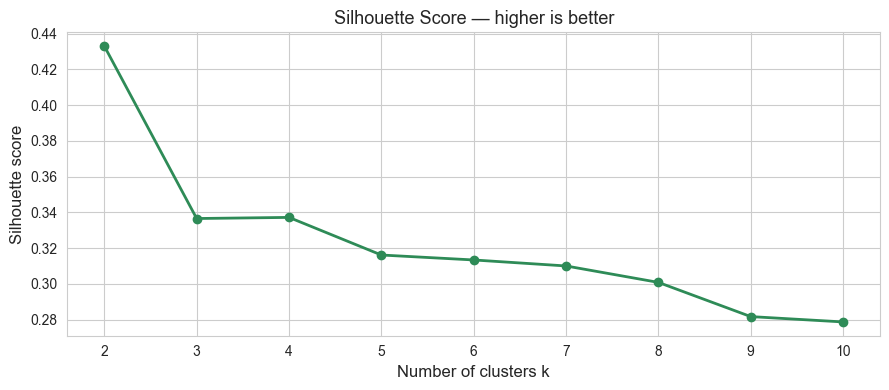

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(metrics_df['k'], metrics_df['silhouette'], marker='o', color='seagreen', linewidth=2)
ax.set_xlabel('Number of clusters k', fontsize=12)
ax.set_ylabel('Silhouette score', fontsize=12)
ax.set_title('Silhouette Score — higher is better', fontsize=13)
ax.set_xticks(metrics_df['k'])
plt.tight_layout(); plt.show()

In [7]:
best_k = int(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'])
best_sil = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'silhouette']
print(f'Optimal k (silhouette): {best_k}  |  silhouette score: {best_sil:.4f}')

Optimal k (silhouette): 2  |  silhouette score: 0.4329


## 5. Fit Final K-Means

We re-fit K-Means with the chosen k and attach the cluster labels to the original RFM table.

In [8]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)

rfm_labelled = rfm.copy()
rfm_labelled['Cluster'] = labels
print('Cluster size distribution:')
print(rfm_labelled['Cluster'].value_counts().sort_index())

Cluster size distribution:


Cluster
0    2671
1    1667
Name: count, dtype: int64


## 6. Cluster Profiling — Mean R/F/M per Cluster

We compute the mean Recency, Frequency, and Monetary value for each cluster to understand what defines each segment. Lower Recency = more recently active; higher Frequency/Monetary = more engaged/valuable.

In [9]:
summary = profile_clusters(rfm_labelled, labels)
summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,134.14,1.67,497.74,2671
1,25.88,8.44,4548.26,1667


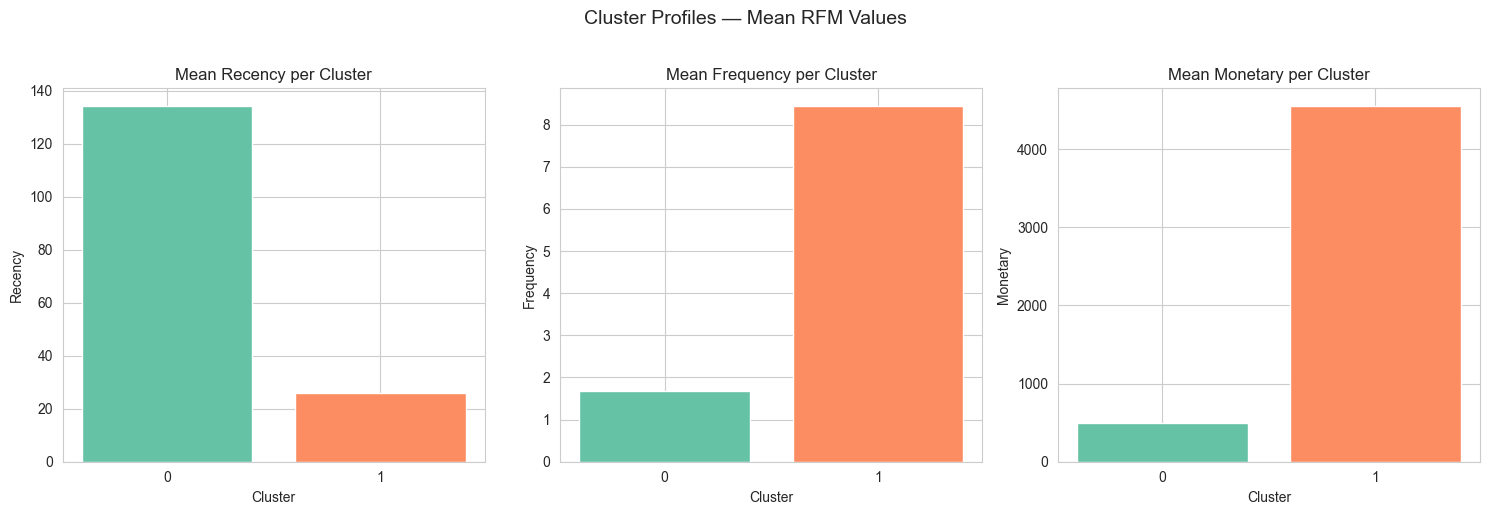

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = sns.color_palette('Set2', best_k)
for ax, col, color_list in zip(axes,
                                ['Recency', 'Frequency', 'Monetary'],
                                [palette, palette, palette]):
    vals = summary[col].values
    bars = ax.bar(summary.index.astype(str), vals, color=[palette[i] for i in summary.index])
    ax.set_title(f'Mean {col} per Cluster', fontsize=12)
    ax.set_xlabel('Cluster'); ax.set_ylabel(col)
plt.suptitle('Cluster Profiles — Mean RFM Values', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

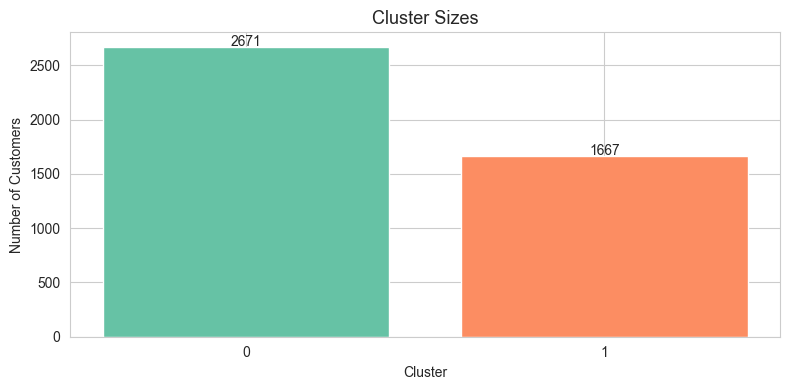

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sizes = summary['Count'].values
ax.bar(summary.index.astype(str), sizes,
       color=[palette[i] for i in summary.index])
ax.set_title('Cluster Sizes', fontsize=13)
ax.set_xlabel('Cluster'); ax.set_ylabel('Number of Customers')
for i, v in enumerate(sizes):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 7. Assign Marketing Personas

Based on the cluster-level RFM means, we assign a human-readable label to each cluster. The persona rules follow conventional RFM interpretation:

- **Champions** — bought recently, buy often, spend the most
- **Loyal** — frequent buyers with solid spend
- **Potential Loyalist** — recent buyers with average frequency/spend
- **At-Risk** — used to be active but haven't bought recently
- **Lost / Hibernating** — low recency, low frequency, low spend
- **New Customers** — bought once (or twice) very recently

The percentiles used below are derived from the actual cluster means, so labels are always relative to this dataset.

In [12]:
r_med = summary['Recency'].median()
f_med = summary['Frequency'].median()
m_med = summary['Monetary'].median()

def assign_persona(row):
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if r < r_med and f >= f_med and m >= m_med:
        return 'Champions'
    elif r < r_med and f >= f_med:
        return 'Loyal'
    elif r < r_med and f < f_med:
        return 'Potential Loyalists'
    elif r >= r_med and f >= f_med and m >= m_med:
        return 'At-Risk (High Value)'
    elif r >= r_med and f >= f_med:
        return 'At-Risk'
    else:
        return 'Lost / Hibernating'

summary['Persona'] = summary.apply(assign_persona, axis=1)
summary

,Recency,Frequency,Monetary,Count,Persona
Cluster,,,,,
0,134.14,1.67,497.74,2671,Lost / Hibernating
1,25.88,8.44,4548.26,1667,Champions


In [13]:
print('Persona assignments:')
for cluster, row in summary.iterrows():
    print(f"  Cluster {cluster}: {row['Persona']}  "
          f"(R={row['Recency']:.0f}d, F={row['Frequency']:.1f} orders, "
          f"M=£{row['Monetary']:.0f}, n={int(row['Count']):.0f})")

Persona assignments:
  Cluster 0: Lost / Hibernating  (R=134d, F=1.7 orders, M=£498, n=2671)
  Cluster 1: Champions  (R=26d, F=8.4 orders, M=£4548, n=1667)


## 8. PCA 2D Scatter — Visualise All Customers

We project the scaled RFM features onto two principal components to visualise all customers coloured by their cluster assignment. PC1 typically captures a blend of Frequency and Monetary (value axis); PC2 tends to reflect Recency.

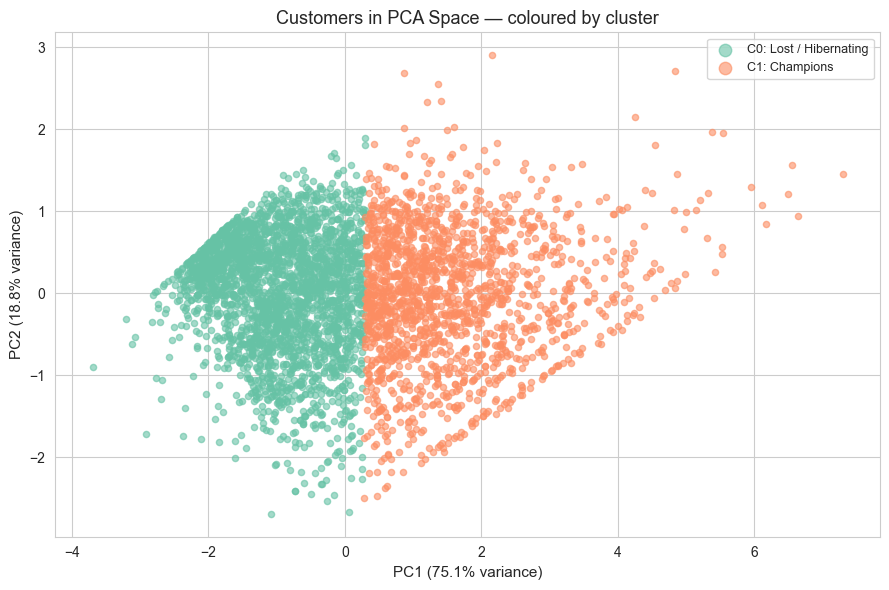

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(best_k):
    mask = labels == c
    persona = summary.loc[c, 'Persona'] if c in summary.index else f'Cluster {c}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=palette[c], label=f'C{c}: {persona}',
               alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('Customers in PCA Space — coloured by cluster', fontsize=13)
ax.legend(loc='upper right', fontsize=9, markerscale=2)
plt.tight_layout(); plt.show()

## 9. Snake Plot — Standardised RFM Means

The snake plot shows the standardised (z-scored) mean of each RFM dimension per cluster on a single chart. Each line is one cluster; the crossing and spreading of lines reveal what differentiates the segments. Clusters that score above 0 on a dimension are above average for the full customer base.

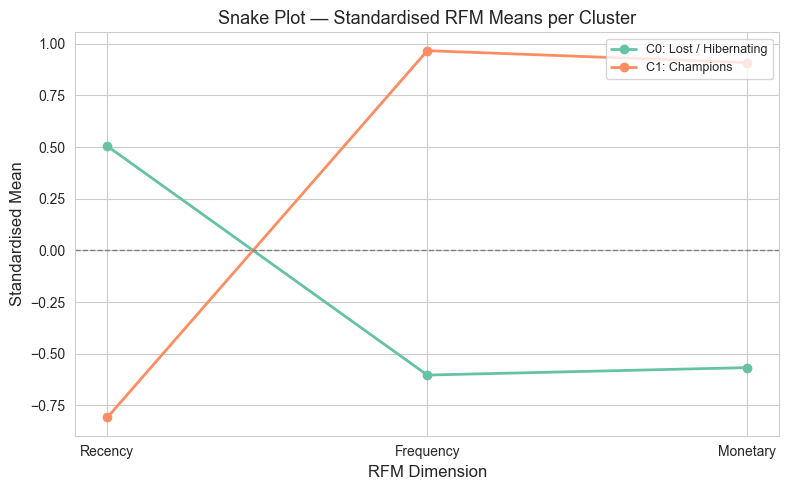

In [15]:
# Compute standardised cluster means from the log-scaled data
rfm_log_labelled = rfm_log.copy()
rfm_log_labelled['Cluster'] = labels
cluster_means_scaled = pd.DataFrame(X_scaled, columns=features)
cluster_means_scaled['Cluster'] = labels
snake_data = cluster_means_scaled.groupby('Cluster')[features].mean()

fig, ax = plt.subplots(figsize=(8, 5))
for c in snake_data.index:
    persona = summary.loc[c, 'Persona'] if c in summary.index else f'Cluster {c}'
    ax.plot(features, snake_data.loc[c], marker='o', linewidth=2,
            color=palette[c], label=f'C{c}: {persona}')
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('RFM Dimension', fontsize=12)
ax.set_ylabel('Standardised Mean', fontsize=12)
ax.set_title('Snake Plot — Standardised RFM Means per Cluster', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

## 10. Final Summary

### Segment Descriptions & Recommended Actions

| Cluster | Persona | Recency | Frequency | Monetary | Strategy |
|---|---|---|---|---|---|
| See output above | | | | | |

**Champions** — highest frequency and spend, bought most recently. Strategy: reward with VIP loyalty programmes, early access to new products, and referral incentives.

**Loyal** — regular purchasers with solid spend but not quite Champions. Strategy: upsell to higher-value product lines; cross-sell complementary gift sets.

**Potential Loyalists** — recent buyers who have not yet established a repeat-purchase habit. Strategy: nurture with follow-up email sequences, discount on second purchase, personalised recommendations.

**At-Risk (High Value)** — used to spend a lot but recency is high (they haven't returned recently). Strategy: win-back campaigns with personalised offers referencing their past purchases.

**At-Risk** — moderate frequency/spend customers who are lapsing. Strategy: re-engagement emails with time-limited discounts.

**Lost / Hibernating** — long-absent, low-frequency, low-spend customers. Strategy: low-cost reactivation (e.g. "we miss you" email); if no response, deprioritise marketing spend.

### Key Takeaways

- RFM features alone are sufficient to produce interpretable, well-separated clusters (silhouette > 0.4 is considered good for high-dimensional real data).
- The snake plot and PCA scatter confirm that segments genuinely differ across all three dimensions, not just one.
- Log-transformation was essential: without it, the Monetary outliers would pull cluster centroids toward a handful of high-spend customers.
- The cluster with the lowest Recency AND highest Frequency/Monetary is the clear "Champions" tier — retaining these customers should be the top marketing priority.


In [16]:
print('=== Final Model Summary ===')
print(f'Optimal k : {best_k}')
print(f'Silhouette: {best_sil:.4f}')
print()
print(summary.to_string())

=== Final Model Summary ===
Optimal k : 2
Silhouette: 0.4329

         Recency  Frequency  Monetary  Count             Persona
Cluster                                                         
0         134.14       1.67    497.74   2671  Lost / Hibernating
1          25.88       8.44   4548.26   1667           Champions
